# 트렌드 분석 (Trend Analysis)

```text
Trend Analysis
│
├── 1. Overall annual temperature
│   ├── 10-year Moving Average
│   ├── Linear Regression
│   ├── Mann-Kendall
│   └── Sen's Slope
│
├── 2. Summer temperature
│   ├── Linear Regression
│   ├── Mann-Kendall
│   └── Sen's Slope
│
├── 3. Winter temperature
│   ├── Linear Regression
│   ├── Mann-Kendall
│   └── Sen's Slope
│
└── 4. Days ≥ 35°C
    ├── Linear Regression
    ├── Mann-Kendall
    └── Sen's Slope
```

In [ ]:
%pip install scipy

Load annual temperature dataset generated in the previous step:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats   # for linear regression: stats.linregress(x, y)

df2 = pd.read_csv("../data/processed/dataset_processed.csv")

## 1. Overall annual temperature

In [5]:
# Load data

annual_temperature = pd.read_csv("../data/processed/annual_temperature.csv")
print(annual_temperature.head())
print(annual_temperature.tail())

   year   avg_temp  avg_min_temp  avg_max_temp
0  1907        NaN           NaN           NaN
1  1908  10.427322      5.799727     15.771858
2  1909  10.608767      5.832603     16.011507
3  1910  10.412055      5.752603     16.008767
4  1911  10.654795      6.035616     16.001644
     year   avg_temp  avg_min_temp  avg_max_temp
113  2022  13.296164      9.207143     18.077808
114  2023  14.109041     10.066027     18.800000
115  2024  14.875410     10.975137     19.539891
116  2025  14.150411     10.218904     18.697808
117  2026        NaN           NaN           NaN


#### 1.1. 10-year Moving Average

Used 10-year moving average for this project. Moving average smooths short-term fluctuations so that the long-term pattern is easier to see.

* 10년 이동평균은 결측 연도(1950~1953, 2026)가 포함된 구간에서는 계산되지 않아 NaN으로 남게 함.
* 10년 구간 안에 최소 5년 데이터가 있을 때도 이동평균을 계산하고 싶으면 `.rolling(window=10, min_periods=5)` 사용

In [ ]:
annual_temperature["moving_avg_10y"] = (
    annual_temperature["avg_temp"]
    .rolling(window=10)
    .mean()
)

In [13]:
print(annual_temperature.loc[annual_temperature["year"] >= 1948].head(15))

# 1950와 1953년의 NaN로 moving_avg_10y의 1950~1962년도가 NaN임을 볼 수 있음

    year   avg_temp  avg_min_temp  avg_max_temp  moving_avg_10y
41  1948  11.758470      6.933880     17.363115       11.060432
42  1949  11.700000      7.400274     17.285479       11.052323
43  1950        NaN           NaN           NaN             NaN
44  1953        NaN           NaN           NaN             NaN
45  1954  11.487945      7.181644     16.598082             NaN
46  1955  11.512877      7.116164     16.744658             NaN
47  1956  10.113388      5.842623     15.067213             NaN
48  1957  10.516438      6.226849     15.723836             NaN
49  1958  11.637260      7.394247     16.790137             NaN
50  1959  12.079726      7.908767     17.048767             NaN
51  1960  12.104645      7.790164     16.991530             NaN
52  1961  12.454521      8.131233     17.206849             NaN
53  1962  11.756986      7.382740     16.536438             NaN
54  1963  11.312877      7.233973     16.066027       11.497666
55  1964  12.221038      8.427049     16

In [15]:
print(annual_temperature.tail(5))

# 2026년 avg_temp NaN 이므로 2026년 이동평균도 NaN

     year   avg_temp  avg_min_temp  avg_max_temp  moving_avg_10y
113  2022  13.296164      9.207143     18.077808       13.317325
114  2023  14.109041     10.066027     18.800000       13.471873
115  2024  14.875410     10.975137     19.539891       13.619386
116  2025  14.150411     10.218904     18.697808       13.672236
117  2026        NaN           NaN           NaN             NaN


Visualize:

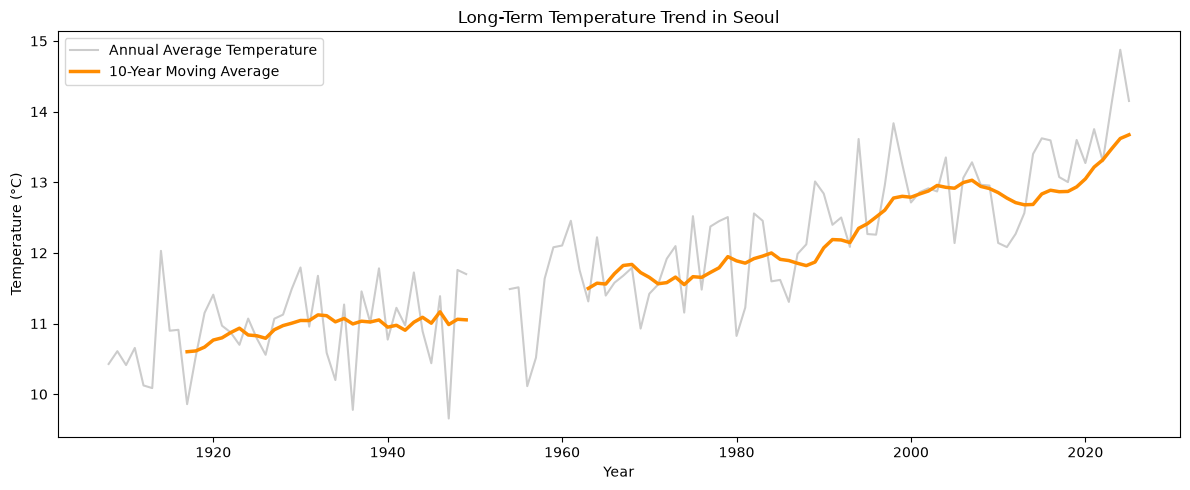

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    annual_temperature["year"],
    annual_temperature["avg_temp"],
    label="Annual Average Temperature",
    alpha=0.4,
    color="gray"
)

plt.plot(
    annual_temperature["year"],
    annual_temperature["moving_avg_10y"],
    label="10-Year Moving Average",
    linewidth=2.5,
    color="darkorange"
)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Long-Term Temperature Trend in Seoul (10-Year Moving Average)")
plt.legend()
plt.tight_layout()
plt.show()

* 전반적으로 연평균 온도는 상승 추세에 있음.
* 10년 이동평균은 결측 연도(1950~1953, 2026)가 포함된 구간에서는 계산되지 않아 NaN으로 남게 하여 그래프에서 보이지 않음.

### 1.2. Linear Regression

* NaN 가 있는 1907, 1950, 1953, 2026년은 drop하고 선형 회귀 분석을 진행한다.

In [22]:
annual_temperature.loc[annual_temperature["avg_temp"].isna()].head(10)

,year,avg_temp,avg_min_temp,avg_max_temp,moving_avg_10y
0,1907,NaN,NaN,NaN,NaN
43,1950,NaN,NaN,NaN,NaN
44,1953,NaN,NaN,NaN,NaN
117,2026,NaN,NaN,NaN,NaN


In [36]:
reg_df = annual_temperature[["year", "avg_temp"]].dropna().sort_values("year")

x_reg= reg_df["year"]
y_reg = reg_df["avg_temp"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x_reg, y_reg)

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r_value ** 2)
print("p-value:", p_value)
print("Standard error:", std_err)
print("Change per 100 years:", slope * 100)

Slope: 0.025993439488541163
Intercept: -39.2750428667257
R²: 0.7013661084927758
p-value: 3.6271958030917613e-31
Standard error: 0.0016026987463640633
Change per 100 years: 2.5993439488541163


* The p-value is extremely low, so the positive linear trend is statistically significant 통계적으로 유의미 (p < 0.05). R² ≈ 0.70 shows that year explains about 70% of the variation in annual average temperature.

Visualize:

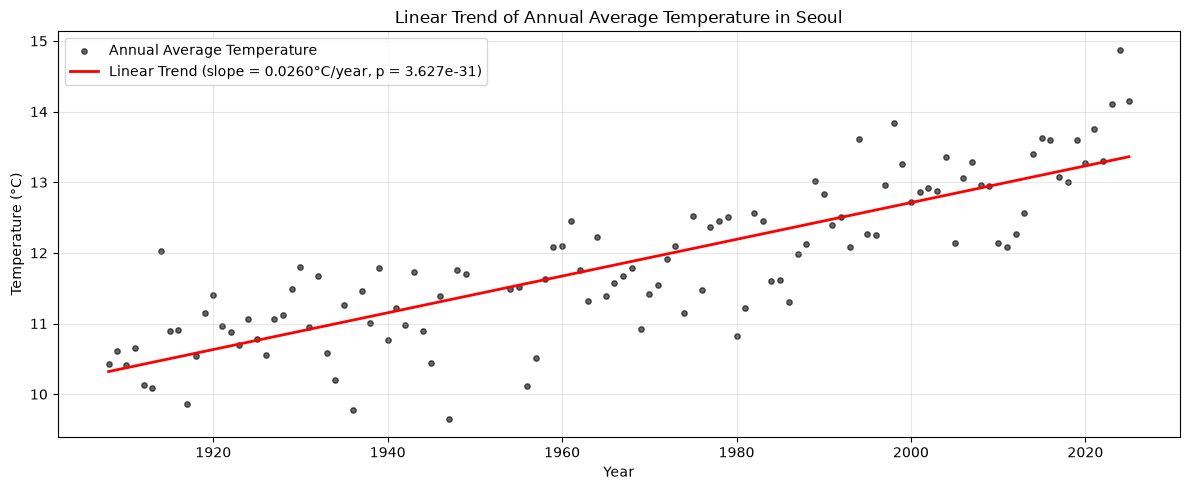

In [31]:
x_reg = reg_df["year"]
y_reg = reg_df["avg_temp"]

trend_line = intercept + slope * x_reg

plt.figure(figsize=(12, 5))

plt.scatter(x_reg, y_reg, color="black", alpha=0.6, s=15, label="Annual Average Temperature")
plt.plot(x_reg, trend_line, color="red", linewidth=2, label=f"Linear Trend (slope = {slope:.4f}°C/year, p = {p_value:.4g})")

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Linear Trend of Annual Average Temperature in Seoul")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

* 연평균 온도는 상승 추세에 있음. 100년 동안 서울시 연평균 온도는 ~2.6°C 정도 상승하였음.

### 1.3. Mann–Kendall Test

Used `pymannkendall` package rather than implementing the test. Data should be sorted without NaN.

결과 값에는 보통 아래 정보가 들어 있음:
* trend: increasing / decreasing / no trend
* p: p-value
* Tau: Kendall’s Tau
* slope: Sen’s slope (패키지에 따라 제공)

In [ ]:
%pip install pymannkendall

In [32]:
import pymannkendall as mk

y_reg = reg_df["avg_temp"]

result = mk.original_test(y_reg)
print(result)


Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(10.393026146112506), Tau=np.float64(0.6590591523055426), s=np.float64(4245.0), var_s=166750.33333333334, slope=np.float64(0.027240230203916294), intercept=np.float64(10.201063979780098))


In [33]:
print("Trend:", result.trend)
print("p-value:", result.p)
if result.p < 0.05:
    print(" > 통계적으로 유의한 추세가 있습니다.")
else:
    print(" > 통계적으로 유의한 추세가 확인되지 않았습니다.")
print("Kendall's Tau:", result.Tau)
print("Sen's slope:", result.slope)

Trend: increasing
p-value: 0.0
 > 통계적으로 유의한 추세가 있습니다.
Kendall's Tau: 0.6590591523055426
Sen's slope: 0.027240230203916294


* Trend: increasing & p-value: 0.0 → statistically significant increasing monotonic trend (통계적으로 유의미한 단조 증가 추세).
* Sen's slope: 0.027°C/year → estimated long-term increase is approximately 2.7°C / 100 year
    * Note: Sen's slope provides a robust estimate of the trend magnitude alongside the Mann–Kendall significance test.

## 2. Summer temperature 

In [34]:
# Load data

seasonal_temperature = pd.read_csv("../data/processed/seasonal_temperature.csv")
print(seasonal_temperature.head())
print(seasonal_temperature.tail())

   season_year  summer_avg_temp  winter_avg_temp
0         1907              NaN        -3.798901
1         1908        22.872826        -2.157778
2         1909        23.510870        -3.020000
3         1910        22.463043        -3.632222
4         1911        22.961957        -2.287912
     season_year  summer_avg_temp  winter_avg_temp
112         2021        25.628261        -0.905556
113         2022        25.481522        -0.778889
114         2023        25.784783         1.431868
115         2024        26.865217        -0.221111
116         2025        27.052174         0.027778


### 2.1. Linear Regression

In [39]:
reg_df_summer = seasonal_temperature[["season_year", "summer_avg_temp"]].dropna().sort_values("season_year")

x_reg_summer = reg_df_summer["season_year"]
y_reg_summer = reg_df_summer["summer_avg_temp"]

summer_slope, summer_intercept, summer_r, summer_p, summer_std = (stats.linregress(x_reg_summer, y_reg_summer))

print("Summer slope:", summer_slope)
print("Summer intercept:", summer_intercept)
print("Summer R²:", summer_r ** 2)
print("Summer p-value:", summer_p)
print("Summer standard error:", summer_std)
print("Summer change per 100 years:", summer_slope * 100)

Summer slope: 0.01694469866832934
Summer intercept: -9.266864551692205
Summer R²: 0.32690981494878474
Summer p-value: 2.488310112101739e-11
Summer standard error: 0.002287269176029003
Summer change per 100 years: 1.694469866832934


* The p-value is extremely low, so the positive linear trend is statistically significant 통계적으로 유의미 (p < 0.05). The relatively low R² ≈ 0.33 shows that year explains about 33% of the variation in annual average temperature.
* Estimated long-term increase is approximately 1.7°C / 100 year

Visualize:

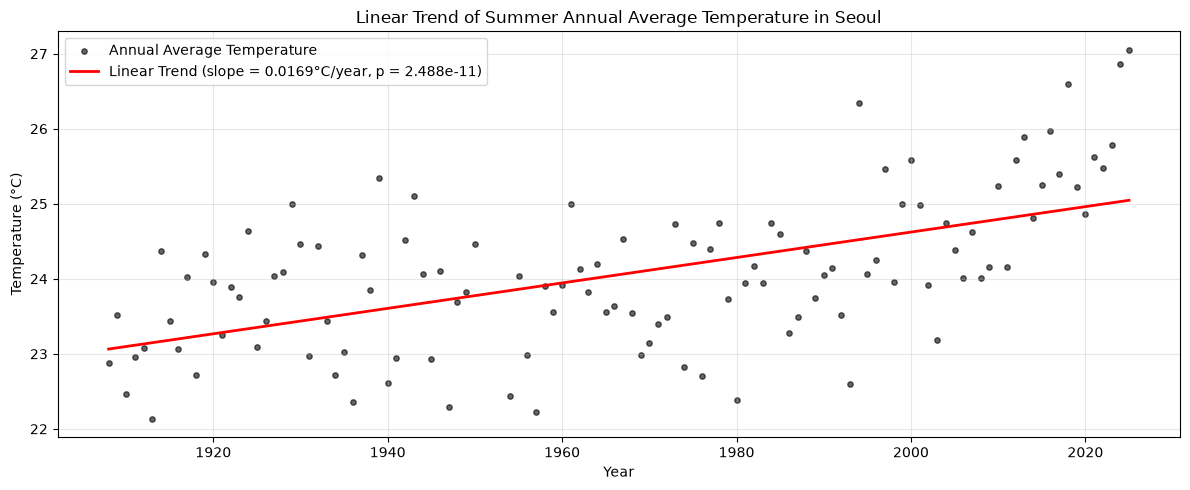

In [44]:
x_reg_summer = reg_df_summer["season_year"]
y_reg_summer = reg_df_summer["summer_avg_temp"]

trend_line_summer = summer_intercept + summer_slope * x_reg_summer

plt.figure(figsize=(12, 5))

plt.scatter(x_reg_summer, y_reg_summer, color="black", alpha=0.6, s=15, label="Annual Average Temperature")
plt.plot(x_reg_summer, trend_line_summer, color="red", linewidth=2, label=f"Linear Trend (slope = {summer_slope:.4f}°C/year, p = {summer_p:.4g})")

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Linear Trend of Summer Annual Average Temperature in Seoul")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

* 100년 동안 서울시 여름 연평균 온도는 ~1.7°C 정도 상승하였음.

### 2.2. Mann–Kendall Test

In [37]:
y_reg_summer = reg_df_summer["summer_avg_temp"]

summer_result = mk.original_test(y_reg_summer)

print("Summer trend:", summer_result.trend)
print("Summer p-value:", summer_result.p)
print("Summer Sen's slope:", summer_result.slope)

Summer trend: increasing
Summer p-value: 6.787459483348357e-10
Summer Sen's slope: 0.017481884057971058


* Trend: increasing & p-value: ~0.0 → statistically significant increasing monotonic trend (통계적으로 유의미한 단조 증가 추세).
* Sen's slope: 0.017°C/year → estimated long-term increase is approximately 1.7°C / 100 year
    * Note: Sen's slope provides a robust estimate of the trend magnitude alongside the Mann–Kendall significance test.

## 3. Winter temperature

In [38]:
# Load data if not done yet in the 2. Summer temperature section

#seasonal_temperature = pd.read_csv("../data/processed/seasonal_temperature.csv")

print(seasonal_temperature.head())
print(seasonal_temperature.tail())

   season_year  summer_avg_temp  winter_avg_temp
0         1907              NaN        -3.798901
1         1908        22.872826        -2.157778
2         1909        23.510870        -3.020000
3         1910        22.463043        -3.632222
4         1911        22.961957        -2.287912
     season_year  summer_avg_temp  winter_avg_temp
112         2021        25.628261        -0.905556
113         2022        25.481522        -0.778889
114         2023        25.784783         1.431868
115         2024        26.865217        -0.221111
116         2025        27.052174         0.027778


### 3.1. Linear Regression

In [40]:
reg_df_winter = seasonal_temperature[["season_year", "winter_avg_temp"]].dropna().sort_values("season_year")

x_reg_winter = reg_df_winter["season_year"]
y_reg_winter = reg_df_winter["winter_avg_temp"]

winter_slope, winter_intercept, winter_r, winter_p, winter_std = (stats.linregress(x_reg_winter, y_reg_winter))

print("Winter slope:", winter_slope)
print("Winter intercept:", winter_intercept)
print("Winter R²:", winter_r ** 2)
print("Winter p-value:", winter_p)
print("Winter standard error:", winter_std)
print("Winter change per 100 years:", winter_slope * 100)

Winter slope: 0.02897529418649979
Winter intercept: -58.69059251603398
Winter R²: 0.34156024507998445
Winter p-value: 5.678997474654642e-12
Winter standard error: 0.003767903681411951
Winter change per 100 years: 2.897529418649979


* The p-value is extremely low, so the positive linear trend is statistically significant 통계적으로 유의미 (p < 0.05). The relatively low R² ≈ 0.34 shows that year explains about 34% of the variation in annual average temperature.
* Estimated long-term increase is approximately 2.9°C / 100 year

Visualize:

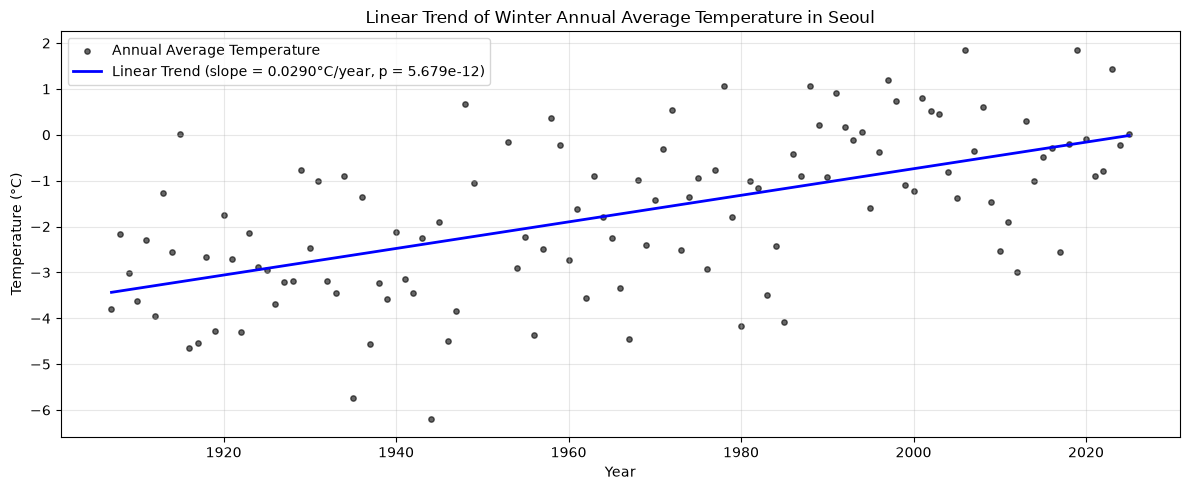

In [45]:
x_reg_winter = reg_df_winter["season_year"]
y_reg_winter = reg_df_winter["winter_avg_temp"]

trend_line_winter = winter_intercept + winter_slope * x_reg_winter

plt.figure(figsize=(12, 5))

plt.scatter(x_reg_winter, y_reg_winter, color="black", alpha=0.6, s=15, label="Annual Average Temperature")
plt.plot(x_reg_winter, trend_line_winter, color="blue", linewidth=2, label=f"Linear Trend (slope = {winter_slope:.4f}°C/year, p = {winter_p:.4g})")

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Linear Trend of Winter Annual Average Temperature in Seoul")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

* 100년 동안 서울시 겨울 연평균 온도는 ~2.9°C 정도 상승하였음.

### 3.2. Mann–Kendall Test

In [41]:
y_reg_winter = reg_df_winter["winter_avg_temp"]

winter_result = mk.original_test(y_reg_winter)

print("Winter trend:", winter_result.trend)
print("Winter p-value:", winter_result.p)
print("Winter Sen's slope:", winter_result.slope)

Winter trend: increasing
Winter p-value: 2.2304091906732992e-10
Winter Sen's slope: 0.030000000000000006


* Trend: increasing & p-value: ~0.0 → statistically significant increasing monotonic trend (통계적으로 유의미한 단조 증가 추세).
* Sen's slope: 0.030°C/year → estimated long-term increase is approximately 3.0°C / 100 year
    * Note: Sen's slope provides a robust estimate of the trend magnitude alongside the Mann–Kendall significance test.

> 서울의 여름(6월~8월)과 겨울(12월~2월)의 평균온도는 증가 추세에 있으며, 100년 동안 여름 평균온도 증가보다 겨울 평균온도 증가가 +1.2°C 정도 높음 (x1.7) (여름 1.7°C vs 겨울 2.9°C).

## 4. Days ≥ 35°C

In [42]:
annual_over_35 = pd.read_csv("../data/processed/annual_over_35.csv")

print(annual_over_35.head())
print(annual_over_35.tail())

   year  days_over_35
0  1907             0
1  1908             0
2  1909             1
3  1910             0
4  1911             0
     year  days_over_35
113  2022             2
114  2023             1
115  2024             6
116  2025            13
117  2026             7


### 4.1. Linear Regression

In [43]:
reg_df_over_35 = annual_over_35[["year", "days_over_35"]].dropna().sort_values("year")

x_reg_over_35 = reg_df_over_35["year"]
y_reg_over_35 = reg_df_over_35["days_over_35"]

slope_35, intercept_35, r_35, p_35, std_35 = stats.linregress(x_reg_over_35, y_reg_over_35)

print("Over 35 slope:", slope_35)
print("Over 35 intercept:", intercept_35)
print("Over 35 R²:", r_35 ** 2)
print("Over 35 p-value:", p_35)
print("Over 35 standard error:", std_35)
print("Over 35 change per 100 years:", slope_35 * 100)

Over 35 slope: 0.0034794728460772386
Over 35 intercept: -4.173776438127689
Over 35 R²: 0.0006474033129439662
Over 35 p-value: 0.7844720310383352
Over 35 standard error: 0.012692768842844223
Over 35 change per 100 years: 0.34794728460772384


* 통계적으로 유의하지 않음 (p = 0.784 > 0.05). 또한 R² ≈ 0.00065로 매우 낮아, 장기적으로 35°C 이상인 날의 수가 증가한다고 볼 수 있는 선형 추세가 거의 나타나지 않음. 100년당 약 0.35일 증가라는 추정치도 통계적으로 신뢰할 만한 증가 추세라고 해석하기 어려움.


Visualize:

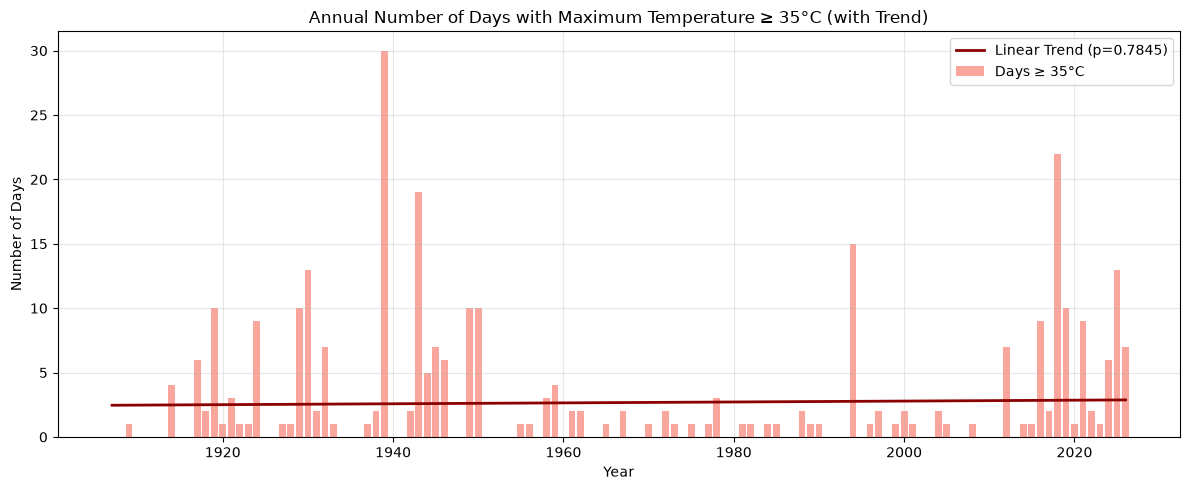

In [47]:
x_reg_over_35 = reg_df_over_35["year"]
y_reg_over_35 = reg_df_over_35["days_over_35"]

trend_35 = intercept_35 + slope_35 * x_reg_over_35

plt.figure(figsize=(12, 5))
plt.bar(x_reg_over_35, y_reg_over_35, color="salmon", alpha=0.7, label="Days ≥ 35°C")
plt.plot(x_reg_over_35, trend_35, color="darkred", linewidth=2, label=f"Linear Trend (p={p_35:.4g})")
plt.xlabel("Year")
plt.ylabel("Number of Days")
plt.title("Annual Number of Days with Maximum Temperature ≥ 35°C (with Trend)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

* Regression line이 거의 일직선이고 bar graph에서도 볼 수 있듯이 35도 이상인 날의 수가 년마다 증가한다고 볼 수 없음. 2020년대에는 35도 이상의 날이 5~15일인 구간에 있는데 언제까지 지속될지 알 수 없음.

### 4.2. Mann–Kendall Test

In [48]:
y_reg_over_35 = reg_df_over_35["days_over_35"]

result_35 = mk.original_test(y_reg_over_35)

print("Over 35 Trend:", result_35.trend)
print("Over 35 p-value:", result_35.p)
print("Over 35 Sen's slope:", result_35.slope)

Over 35 Trend: no trend
Over 35 p-value: 0.4750867171372275
Over 35 Sen's slope: 0.0


* Not statistically significant trend because p = 0.475 > 0.05; the Sen’s slope of 0.0 likewise suggests essentially no detectable monotonic change in the annual number of days ≥35°C.

## 5. Saving the trend-analysis results

In [49]:
trend_results = pd.DataFrame({
    "dataset": [
        "Annual Average Temperature",
        "Summer Average Temperature",
        "Winter Average Temperature",
        "Days ≥ 35°C"
    ],
    "linear_slope_per_year": [
        slope,
        summer_slope,
        winter_slope,
        slope_35
    ],
    "linear_p_value": [
        p_value,
        summer_p,
        winter_p,
        p_35
    ],
    "linear_r_value": [
        r_value,
        summer_r,
        winter_r,
        r_35
    ],
    "mann_kendall_trend": [
        result.trend,
        summer_result.trend,
        winter_result.trend,
        result_35.trend
    ],
    "mann_kendall_p_value": [
        result.p,
        summer_result.p,
        winter_result.p,
        result_35.p
    ],
    "sen_slope": [
        result.slope,
        summer_result.slope,
        winter_result.slope,
        result_35.slope
    ]
})

print(trend_results)

trend_results.to_csv(
    "../data/processed/trend_analysis_results.csv",
    index=False,
    encoding="utf-8-sig"
)

                      dataset  linear_slope_per_year  linear_p_value  \
0  Annual Average Temperature               0.025993    3.627196e-31   
1  Summer Average Temperature               0.016945    2.488310e-11   
2  Winter Average Temperature               0.028975    5.678997e-12   
3                 Days ≥ 35°C               0.003479    7.844720e-01   

   linear_r_value mann_kendall_trend  mann_kendall_p_value  sen_slope  
0        0.837476         increasing          0.000000e+00   0.027240  
1        0.571760         increasing          6.787459e-10   0.017482  
2        0.584432         increasing          2.230409e-10   0.030000  
3        0.025444           no trend          4.750867e-01   0.000000  


> Note: 

> Because the data are a long climate time series, the basic Mann–Kendall test should not automatically be treated as the final statistical answer if serial autocorrelation is present. Autocorrelation can affect the significance of the MK test, and specialized approaches such as trend-free prewhitening or other autocorrelation-aware methods are commonly used in climate/hydrological trend analysis.

> The basic MK test was carried out to understand the results, but before writing the final methodology/report, should check the annual series for autocorrelation and decide whether an autocorrelation-adjusted MK test is appropriate.

### Files saved

* `/data/processed/trend_analysis_results.csv`